## ***Five confusion matrices, a table showing the statistical significance (p-values from McNemar's test) comparing each model's performance on the 70% train set, 20% test set, 10% validation set, and a bar chart visualizing the Test ROC AUC for all models.***


--- All 5 Confusion Matrices on 70% SMOTE-Resampled Training Set ---


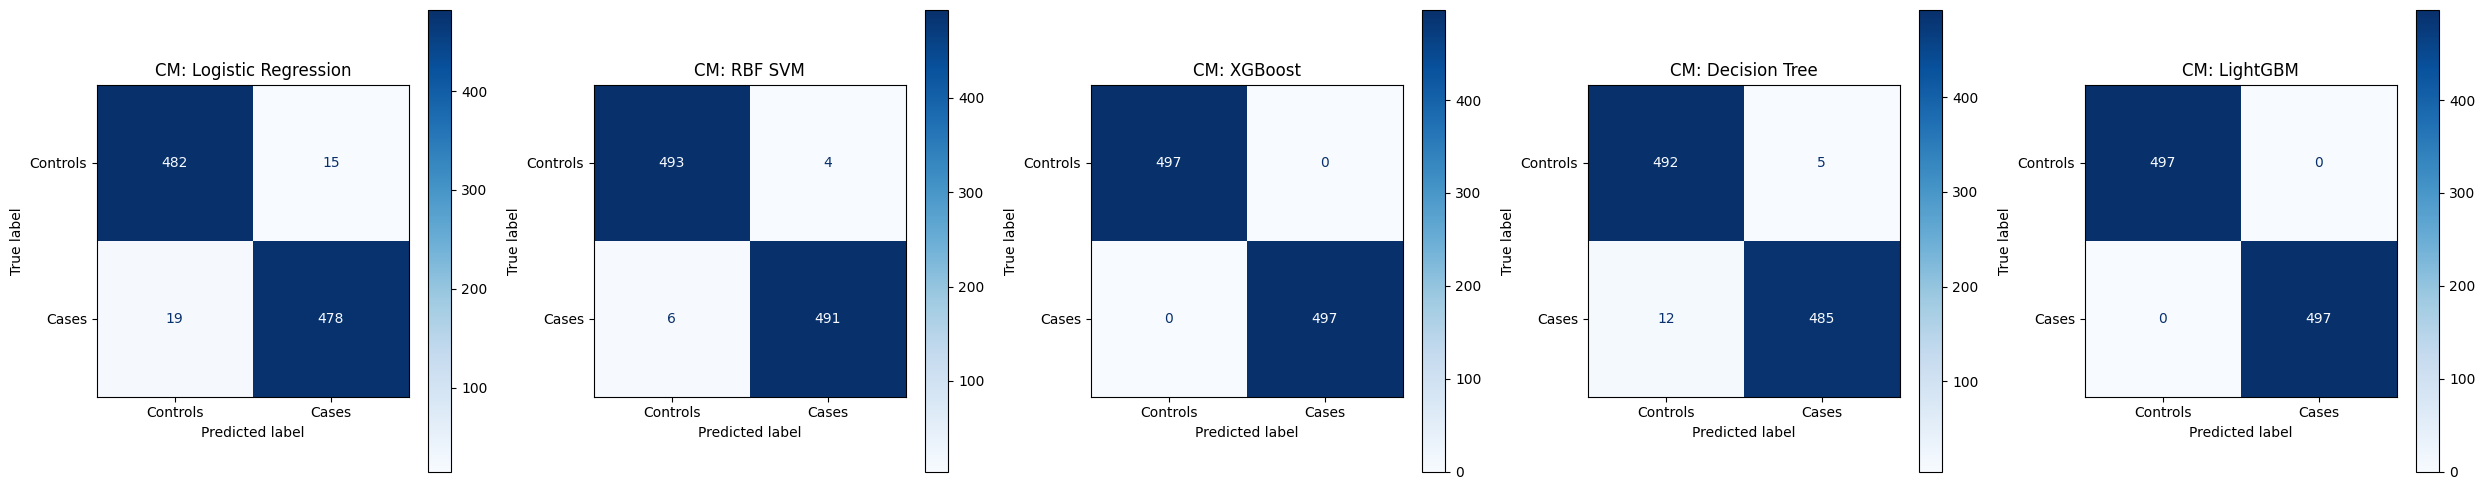


--- Statistical Significance (McNemar's Test) on 70% SMOTE-Resampled Training Set ---


,Logistic Regression,RBF SVM,XGBoost,Decision Tree,LightGBM
Logistic Regression,1.000000e+00,0.000027,1.518560e-08,0.008529,1.518560e-08
RBF SVM,2.678522e-05,1.000000,4.426526e-03,0.210903,4.426526e-03
XGBoost,1.518560e-08,0.004427,1.000000e+00,0.000104,1.000000e+00
Decision Tree,8.528852e-03,0.210903,1.042119e-04,1.000000,1.042119e-04
LightGBM,1.518560e-08,0.004427,1.000000e+00,0.000104,1.000000e+00



Note: A low p-value (e.g., < 0.05) indicates a statistically significant difference in performance between the two models.

--- Analysis of McNemar's Test Results (70% SMOTE-Resampled Training Set) ---
  'Logistic Regression' and 'RBF SVM' are statistically different (p=0.0000)
  'Logistic Regression' and 'XGBoost' are statistically different (p=0.0000)
  'Logistic Regression' and 'Decision Tree' are statistically different (p=0.0085)
  'Logistic Regression' and 'LightGBM' are statistically different (p=0.0000)
  'RBF SVM' and 'XGBoost' are statistically different (p=0.0044)
  'RBF SVM' and 'Decision Tree' are NOT statistically different (p=0.2109)
  'RBF SVM' and 'LightGBM' are statistically different (p=0.0044)
  'XGBoost' and 'Decision Tree' are statistically different (p=0.0001)
  'XGBoost' and 'LightGBM' are NOT statistically different (p=1.0000)
  'Decision Tree' and 'LightGBM' are statistically different (p=0.0001)

--- Comparative Analysis: Training ROC AUC for All Models (Bar

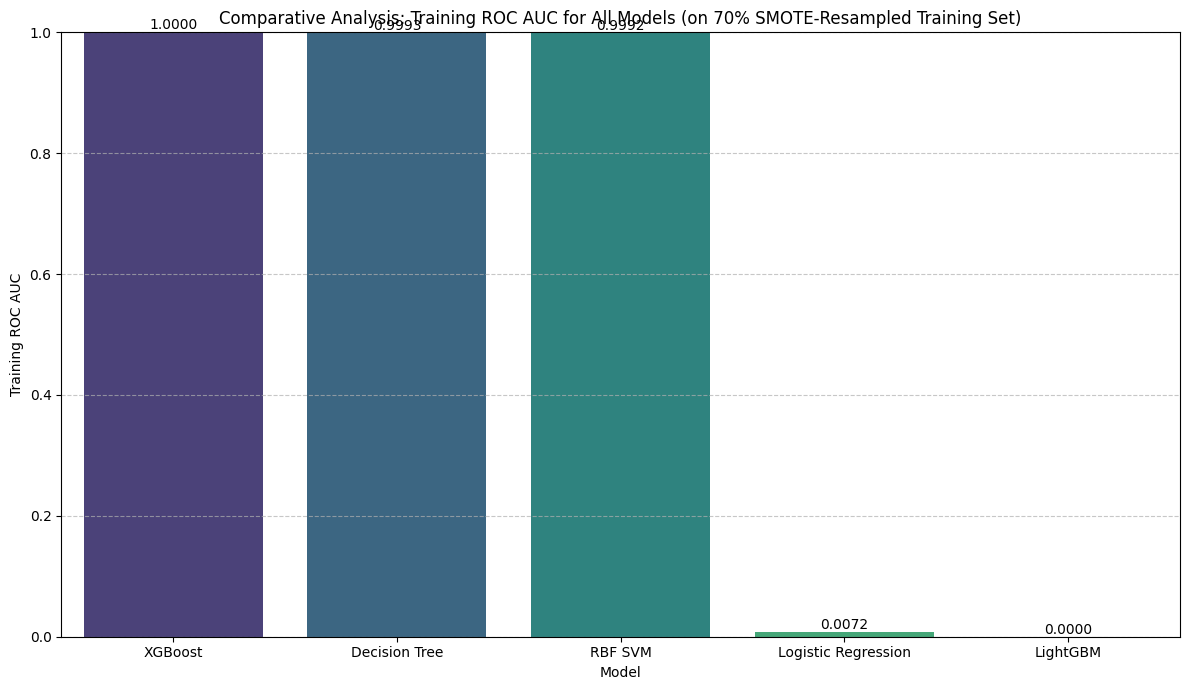


--- Top Performing Models on 70% SMOTE-Resampled Training Set ---

Model with the highest F1-score: XGBoost (F1-score: 1.0000)
Model with the highest ROC AUC: XGBoost (ROC AUC: 1.0000)


,Training F1-score,Training ROC AUC
Model,,
Logistic Regression,0.9657,0.0072
RBF SVM,0.9899,0.9992
XGBoost,1.0000,1.0000
Decision Tree,0.9828,0.9993
LightGBM,1.0000,0.0000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, f1_score
from statsmodels.stats.contingency_tables import mcnemar
from itertools import combinations

# Ensure y_train is defined and converted to numeric for consistent metric calculation
if 'y_train' in locals():
    y_train_numeric = y_train.map({'Cases': 1, 'Controls': 0}) if y_train.dtype == 'object' else y_train
else:
    print("Error: y_train not found. Please ensure previous data splitting and SMOTE cells have been run.")
    y_train_numeric = pd.Series() # Create an empty series to avoid errors

# Define models (assuming best_model_X variables are available from previous executions)
models = {
    "Logistic Regression": best_model_logreg if 'best_model_logreg' in locals() else None,
    "RBF SVM": best_model_svm if 'best_model_svm' in locals() else None,
    "XGBoost": best_model_xgb if 'best_model_xgb' in locals() else None,
    "Decision Tree": best_model_dt if 'best_model_dt' in locals() else None,
    "LightGBM": best_model_lgbm if 'best_model_lgbm' in locals() else None
}

if X_train.empty or y_train_numeric.empty:
    print("X_train or y_train is empty. Skipping all visualizations and statistical tests for the training set.")
else:
    # --- 1. Display all 5 Confusion Matrices for the 70% SMOTE-Resampled Training Set ---
    print("\n--- All 5 Confusion Matrices on 70% SMOTE-Resampled Training Set ---")

    fig, axes = plt.subplots(1, 5, figsize=(25, 5)) # Adjust figsize as needed
    axes = axes.flatten()

    for i, (model_name, model) in enumerate(models.items()):
        if model is not None:
            y_pred_train = model.predict(X_train)
            # Ensure predictions are numeric for confusion matrix
            if pd.api.types.is_string_dtype(y_pred_train):
                y_pred_train_numeric = pd.Series(y_pred_train, index=y_train_numeric.index).map({'Cases': 1, 'Controls': 0})
            else:
                y_pred_train_numeric = pd.Series(y_pred_train, index=y_train_numeric.index)

            cm = confusion_matrix(y_train_numeric, y_pred_train_numeric)
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Controls', 'Cases'])
            disp.plot(cmap=plt.cm.Blues, ax=axes[i], values_format='d')
            axes[i].set_title(f'CM: {model_name}')
        else:
            axes[i].set_title(f'CM: {model_name}\n(Model not found)')
            axes[i].axis('off') # Turn off axis if model not found

    plt.tight_layout()
    plt.show()
    plt.close()

    # --- 2. Calculate Statistical Significance (McNemar's Test) between models on 70% SMOTE-Resampled Training Set ---
    print("\n--- Statistical Significance (McNemar's Test) on 70% SMOTE-Resampled Training Set ---")

    model_predictions_train = {}
    for model_name, model in models.items():
        if model is not None:
            y_pred_train = model.predict(X_train)
            if pd.api.types.is_string_dtype(y_pred_train):
                # Ensure predictions Series have the same index as y_train_numeric
                model_predictions_train[model_name] = pd.Series(y_pred_train, index=y_train_numeric.index).map({'Cases': 1, 'Controls': 0})
            else:
                # Ensure predictions Series have the same index as y_train_numeric
                model_predictions_train[model_name] = pd.Series(y_pred_train, index=y_train_numeric.index)
        else:
            model_predictions_train[model_name] = None

    model_names_list_train = [name for name, preds in model_predictions_train.items() if preds is not None]
    p_value_matrix_train = pd.DataFrame(np.nan, index=model_names_list_train, columns=model_names_list_train)

    for model1_name, model2_name in combinations(model_names_list_train, 2):
        preds1 = model_predictions_train[model1_name]
        preds2 = model_predictions_train[model2_name]

        # Calculate agreement/disagreement for McNemar's test
        # b: model1 correct, model2 incorrect
        # c: model1 incorrect, model2 correct
        b = ((y_train_numeric == preds1) & (y_train_numeric != preds2)).sum()
        c = ((y_train_numeric != preds1) & (y_train_numeric == preds2)).sum()

        if b + c > 0: # McNemar's test requires b+c > 0
            # Create a 2x2 contingency table for McNemar's test (correctly classified by one, misclassified by other)
            table = np.array([[0, b], [c, 0]])
            result = mcnemar(table, exact=False) # exact=False for chi-squared approximation
            p_value_matrix_train.loc[model1_name, model2_name] = result.pvalue
            p_value_matrix_train.loc[model2_name, model1_name] = result.pvalue # Symmetric
        else:
            # If b+c is 0, it means models agree perfectly on all predictions or disagree on none,
            # suggesting no significant difference. Set p-value to 1.0.
            p_value_matrix_train.loc[model1_name, model2_name] = 1.0
            p_value_matrix_train.loc[model2_name, model1_name] = 1.0

    # Fill diagonal with 1.0 (model vs itself)
    for name in model_names_list_train:
        p_value_matrix_train.loc[name, name] = 1.0

    display(p_value_matrix_train)
    print("\nNote: A low p-value (e.g., < 0.05) indicates a statistically significant difference in performance between the two models.")

    # --- Analyze McNemar's Test Results ---
    print("\n--- Analysis of McNemar's Test Results (70% SMOTE-Resampled Training Set) ---")
    alpha = 0.05
    for model1_name, model2_name in combinations(model_names_list_train, 2):
        p_value = p_value_matrix_train.loc[model1_name, model2_name]
        if p_value < alpha:
            print(f"  '{model1_name}' and '{model2_name}' are statistically different (p={p_value:.4f})")
        else:
            print(f"  '{model1_name}' and '{model2_name}' are NOT statistically different (p={p_value:.4f})")

    # --- 3. Bar Chart of Training ROC AUC for all models ---
    print("\n--- Comparative Analysis: Training ROC AUC for All Models (Bar Chart) ---")

    # Re-extract and format training metrics to create comparative_training_df reliably
    all_models_training_metrics = {}

    def extract_train_metrics_for_comp_df(model_name, best_model_obj, X_data, y_true_numeric):
        y_pred_raw = best_model_obj.predict(X_data)
        # Convert raw predictions to numeric (0/1) for consistent metric calculation
        if pd.api.types.is_string_dtype(y_pred_raw):
            y_pred = pd.Series(y_pred_raw).map({'Cases': 1, 'Controls': 0})
        else:
            y_pred = y_pred_raw

        y_proba = best_model_obj.predict_proba(X_data)[:, 1] # Assuming positive class is at index 1
        f1 = f1_score(y_true_numeric, y_pred)
        roc_auc = roc_auc_score(y_true_numeric, y_proba)
        all_models_training_metrics[model_name] = {
            'Training F1-score': f'{f1:.4f}',
            'Training ROC AUC': f'{roc_auc:.4f}'
        }

    if 'best_model_logreg' in locals() and best_model_logreg is not None: extract_train_metrics_for_comp_df('Logistic Regression', best_model_logreg, X_train, y_train_numeric)
    if 'best_model_svm' in locals() and best_model_svm is not None: extract_train_metrics_for_comp_df('RBF SVM', best_model_svm, X_train, y_train_numeric)
    if 'best_model_xgb' in locals() and best_model_xgb is not None: extract_train_metrics_for_comp_df('XGBoost', best_model_xgb, X_train, y_train_numeric)
    if 'best_model_dt' in locals() and best_model_dt is not None: extract_train_metrics_for_comp_df('Decision Tree', best_model_dt, X_train, y_train_numeric)
    if 'best_model_lgbm' in locals() and best_model_lgbm is not None: extract_train_metrics_for_comp_df('LightGBM', best_model_lgbm, X_train, y_train_numeric)

    comparative_training_df = pd.DataFrame.from_dict(all_models_training_metrics, orient='index')
    comparative_training_df.index.name = 'Model'


    if not comparative_training_df.empty and 'Training ROC AUC' in comparative_training_df.columns:
        # Ensure 'Training ROC AUC' column is numeric for sorting and plotting
        training_roc_auc_scores = comparative_training_df['Training ROC AUC'].astype(float).sort_values(ascending=False)

        if not training_roc_auc_scores.empty:
            plot_df_roc_auc_train = pd.DataFrame({'Model': training_roc_auc_scores.index, 'Training ROC AUC': training_roc_auc_scores.values})

            plt.figure(figsize=(12, 7))
            sns.barplot(x='Model', y='Training ROC AUC', data=plot_df_roc_auc_train, palette='viridis', hue='Model', legend=False)
            plt.title('Comparative Analysis: Training ROC AUC for All Models (on 70% SMOTE-Resampled Training Set)')
            plt.xlabel('Model')
            plt.ylabel('Training ROC AUC')
            plt.ylim(max(0.0, plot_df_roc_auc_train['Training ROC AUC'].min() - 0.05), 1.0) # Adjust y-axis limit dynamically
            for index, value in enumerate(plot_df_roc_auc_train['Training ROC AUC'].values):
                plt.text(index, value + 0.005, f'{value:.4f}', color='black', ha='center')
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.show()
            plt.close() # Close the figure to free up memory
        else:
            print("No valid Training ROC AUC scores found in comparative_training_df to plot.")
    else:
        print("comparative_training_df not found or is empty, or 'Training ROC AUC' column is missing. Cannot display ROC AUC bar graph.")

    # --- 4. Identify highest F1-score and highest ROC AUC on Training Set ---
    print("\n--- Top Performing Models on 70% SMOTE-Resampled Training Set ---")
    if not comparative_training_df.empty:
        # Ensure columns are numeric for comparison
        comparative_training_df_numeric = comparative_training_df.apply(pd.to_numeric, errors='coerce')

        # Identify the best model for F1-score
        if 'Training F1-score' in comparative_training_df_numeric.columns:
            best_f1_model_train = comparative_training_df_numeric['Training F1-score'].idxmax()
            best_f1_score_train = comparative_training_df_numeric['Training F1-score'].max()
            print(f"\nModel with the highest F1-score: {best_f1_model_train} (F1-score: {best_f1_score_train:.4f})")
        else:
            print("Warning: 'Training F1-score' column not found in comparative_training_df. Cannot identify top F1 model.")

        # Identify the best model for ROC AUC
        if 'Training ROC AUC' in comparative_training_df_numeric.columns:
            best_roc_auc_model_train = comparative_training_df_numeric['Training ROC AUC'].idxmax()
            best_roc_auc_score_train = comparative_training_df_numeric['Training ROC AUC'].max()
            print(f"Model with the highest ROC AUC: {best_roc_auc_model_train} (ROC AUC: {best_roc_auc_score_train:.4f})")
        else:
            print("Warning: 'Training ROC AUC' column not found in comparative_training_df. Cannot identify top ROC AUC model.")

        display(comparative_training_df[['Training F1-score', 'Training ROC AUC']])

    else:
        print("comparative_training_df not found or is empty. Cannot identify top performing models.")


--- All 5 Confusion Matrices on 20% Test Set ---


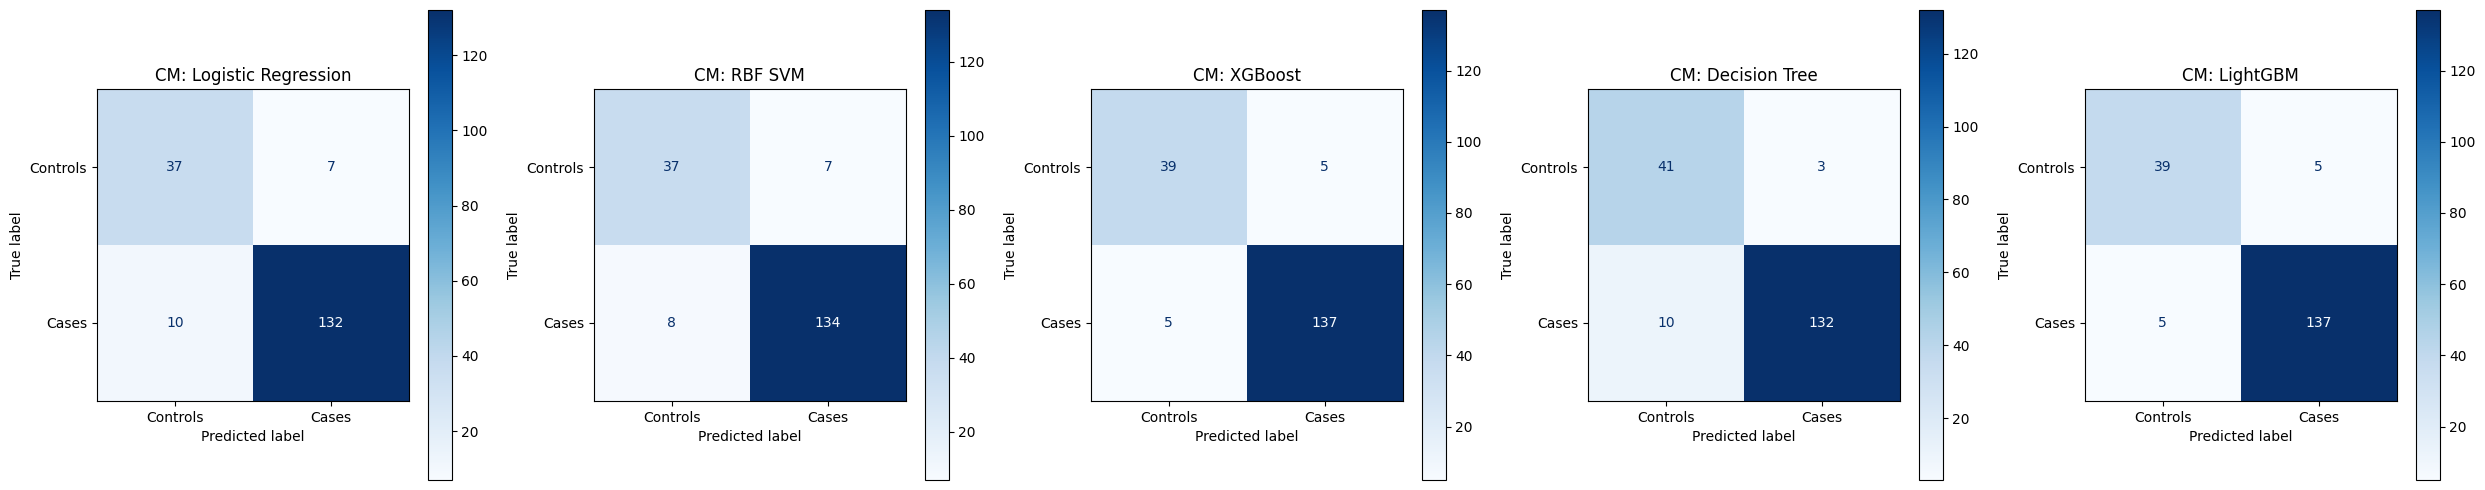


--- Statistical Significance (McNemar's Test) on 20% Test Set ---


,Logistic Regression,RBF SVM,XGBoost,Decision Tree,LightGBM
Logistic Regression,1.000000,0.683091,0.070440,0.453255,0.070440
RBF SVM,0.683091,1.000000,0.182422,0.789268,0.182422
XGBoost,0.070440,0.182422,1.000000,0.546494,1.000000
Decision Tree,0.453255,0.789268,0.546494,1.000000,0.546494
LightGBM,0.070440,0.182422,1.000000,0.546494,1.000000



Note: A low p-value (e.g., < 0.05) indicates a statistically significant difference in performance between the two models.

--- Comparative Analysis: Test ROC AUC for All Models (Bar Chart) ---


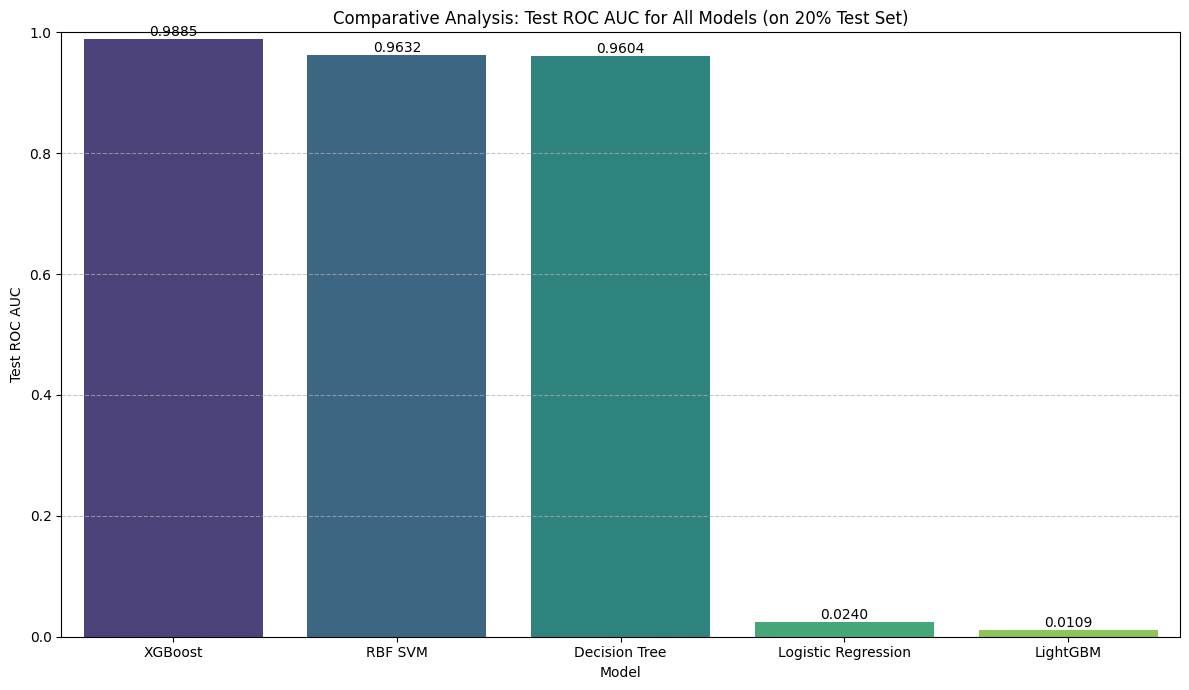

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, accuracy_score
from statsmodels.stats.contingency_tables import mcnemar
from itertools import combinations

# Ensure y_test_numeric is uniformly defined, assuming it was created in previous cells
# If not, create it here, assuming 'Cases' is 1 and 'Controls' is 0
if 'y_test' in locals():
    y_test_numeric = y_test.map({'Cases': 1, 'Controls': 0}) if y_test.dtype == 'object' else y_test
else:
    print("Error: y_test not found. Please ensure previous data splitting cells have been run.")
    y_test_numeric = pd.Series() # Create an empty series to avoid errors

if X_test.empty or y_test_numeric.empty:
    print("X_test or y_test is empty. Skipping all visualizations and statistical tests.")
else:
    # --- 1. Display all 5 Confusion Matrices for the 20% Test Set ---
    print("\n--- All 5 Confusion Matrices on 20% Test Set ---")
    models = {
        "Logistic Regression": best_model_logreg,
        "RBF SVM": best_model_svm,
        "XGBoost": best_model_xgb,
        "Decision Tree": best_model_dt,
        "LightGBM": best_model_lgbm
    }

    fig, axes = plt.subplots(1, 5, figsize=(25, 5)) # Adjust figsize as needed
    axes = axes.flatten()

    for i, (model_name, model) in enumerate(models.items()):
        if model is not None:
            y_pred = model.predict(X_test)
            # Ensure predictions are numeric for confusion matrix
            if pd.api.types.is_string_dtype(y_pred):
                y_pred_numeric = pd.Series(y_pred, index=y_test_numeric.index).map({'Cases': 1, 'Controls': 0})
            else:
                y_pred_numeric = pd.Series(y_pred, index=y_test_numeric.index)

            cm = confusion_matrix(y_test_numeric, y_pred_numeric)
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Controls', 'Cases'])
            disp.plot(cmap=plt.cm.Blues, ax=axes[i], values_format='d')
            axes[i].set_title(f'CM: {model_name}')
        else:
            axes[i].set_title(f'CM: {model_name}\n(Model not found)')
            axes[i].axis('off') # Turn off axis if model not found

    plt.tight_layout()
    plt.show()
    plt.close()

    # --- 2. Calculate Statistical Significance (McNemar's Test) between models on 20% Test Set ---
    print("\n--- Statistical Significance (McNemar's Test) on 20% Test Set ---")

    model_predictions = {}
    for model_name, model in models.items():
        if model is not None:
            y_pred = model.predict(X_test)
            if pd.api.types.is_string_dtype(y_pred):
                # Ensure predictions Series have the same index as y_test_numeric
                model_predictions[model_name] = pd.Series(y_pred, index=y_test_numeric.index).map({'Cases': 1, 'Controls': 0})
            else:
                # Ensure predictions Series have the same index as y_test_numeric
                model_predictions[model_name] = pd.Series(y_pred, index=y_test_numeric.index)
        else:
            model_predictions[model_name] = None

    model_names_list = [name for name, preds in model_predictions.items() if preds is not None]
    p_value_matrix = pd.DataFrame(np.nan, index=model_names_list, columns=model_names_list)

    for model1_name, model2_name in combinations(model_names_list, 2):
        preds1 = model_predictions[model1_name]
        preds2 = model_predictions[model2_name]

        # Calculate agreement/disagreement
        # b: model1 correct, model2 incorrect
        # c: model1 incorrect, model2 correct
        b = ((y_test_numeric == preds1) & (y_test_numeric != preds2)).sum()
        c = ((y_test_numeric != preds1) & (y_test_numeric == preds2)).sum()

        if b + c > 0: # McNemar's test requires b+c > 0
            # Create a 2x2 contingency table for McNemar's test (correctly classified by one, misclassified by other)
            table = np.array([[0, b], [c, 0]])
            result = mcnemar(table, exact=False) # exact=False for chi-squared approximation
            p_value_matrix.loc[model1_name, model2_name] = result.pvalue
            p_value_matrix.loc[model2_name, model1_name] = result.pvalue # Symmetric
        else:
            # If b+c is 0, it means models agree perfectly on all predictions or disagree on none,
            # suggesting no significant difference. Set p-value to 1.0.
            p_value_matrix.loc[model1_name, model2_name] = 1.0
            p_value_matrix.loc[model2_name, model1_name] = 1.0

    # Fill diagonal with 1.0 (model vs itself)
    for name in model_names_list:
        p_value_matrix.loc[name, name] = 1.0

    display(p_value_matrix)
    print("\nNote: A low p-value (e.g., < 0.05) indicates a statistically significant difference in performance between the two models.")


    # --- 3. Bar Chart of Test ROC AUC for all models ---
    print("\n--- Comparative Analysis: Test ROC AUC for All Models (Bar Chart) ---")

    if 'comparative_df' in locals() and not comparative_df.empty and 'Test ROC AUC' in comparative_df.columns:
        roc_auc_scores = comparative_df['Test ROC AUC'].apply(lambda x: float(x)).sort_values(ascending=False)

        # Create a DataFrame for plotting to explicitly define x, y, and hue
        plot_df_roc_auc = pd.DataFrame({'Model': roc_auc_scores.index, 'Test ROC AUC': roc_auc_scores.values})

        plt.figure(figsize=(12, 7))
        sns.barplot(x='Model', y='Test ROC AUC', data=plot_df_roc_auc, palette='viridis', hue='Model', legend=False)
        plt.title('Comparative Analysis: Test ROC AUC for All Models (on 20% Test Set)')
        plt.xlabel('Model')
        plt.ylabel('Test ROC AUC')
        plt.ylim(max(0.0, plot_df_roc_auc['Test ROC AUC'].min() - 0.05), 1.0) # Adjust y-axis limit dynamically
        for index, value in enumerate(plot_df_roc_auc['Test ROC AUC'].values):
            plt.text(index, value + 0.005, f'{value:.4f}', color='black', ha='center')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print("comparative_df not found or is empty, or 'Test ROC AUC' column is missing. Cannot display ROC AUC bar graph.")


In [ ]:
print("--- Comparative Analysis of All Models on Test Set ---")
display(comparative_df[['Test F1-score', 'Test ROC AUC']])

# Identify the best model for F1-score
best_f1_model = comparative_df['Test F1-score'].astype(float).idxmax()
best_f1_score = comparative_df['Test F1-score'].astype(float).max()
print(f"\nModel with the highest F1-score: {best_f1_model} (F1-score: {best_f1_score:.4f})")

# Identify the best model for ROC AUC
best_roc_auc_model = comparative_df['Test ROC AUC'].astype(float).idxmax()
best_roc_auc_score = comparative_df['Test ROC AUC'].astype(float).max()
print(f"Model with the highest ROC AUC: {best_roc_auc_model} (ROC AUC: {best_roc_auc_score:.4f})")

--- Comparative Analysis of All Models on Test Set ---


,Test F1-score,Test ROC AUC
Model,,
Logistic Regression,0.9395,0.0240
RBF SVM,0.9470,0.9632
XGBoost,0.9648,0.9885
Decision Tree,0.9531,0.9604
LightGBM,0.9648,0.0109



Model with the highest F1-score: XGBoost (F1-score: 0.9648)
Model with the highest ROC AUC: XGBoost (ROC AUC: 0.9885)



--- All 5 Confusion Matrices on 10% Validation Set ---


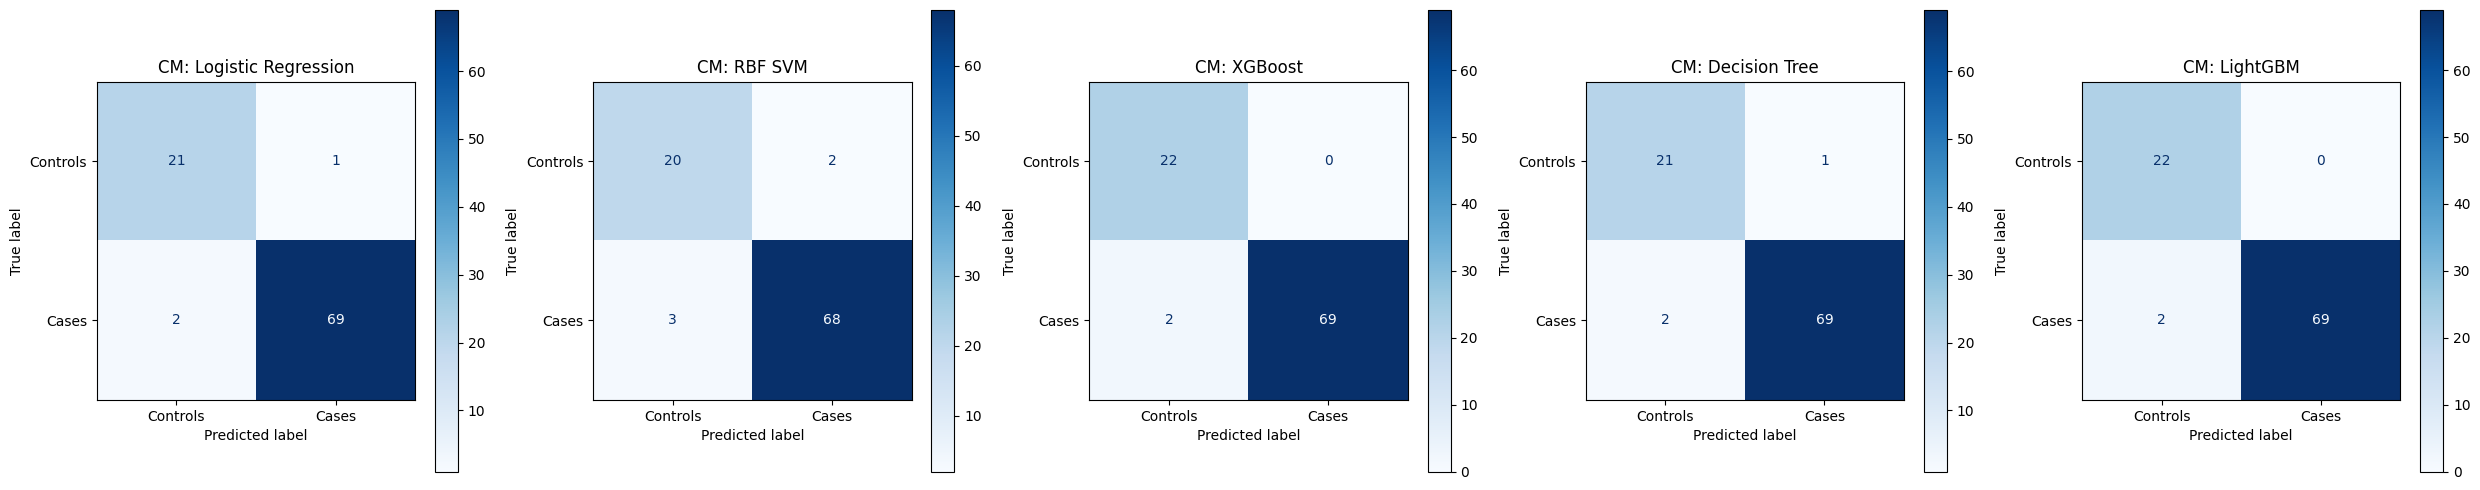


--- Statistical Significance (McNemar's Test) on 10% Validation Set ---


,Logistic Regression,RBF SVM,XGBoost,Decision Tree,LightGBM
Logistic Regression,1.000000,0.617075,1.000000,0.683091,1.000000
RBF SVM,0.617075,1.000000,0.371093,0.723674,0.371093
XGBoost,1.000000,0.371093,1.000000,1.000000,1.000000
Decision Tree,0.683091,0.723674,1.000000,1.000000,1.000000
LightGBM,1.000000,0.371093,1.000000,1.000000,1.000000



Note: A low p-value (e.g., < 0.05) indicates a statistically significant difference in performance between the two models.

--- Analysis of McNemar's Test Results (10% Validation Set) ---
  'Logistic Regression' and 'RBF SVM' are NOT statistically different (p=0.6171)
  'Logistic Regression' and 'XGBoost' are NOT statistically different (p=1.0000)
  'Logistic Regression' and 'Decision Tree' are NOT statistically different (p=0.6831)
  'Logistic Regression' and 'LightGBM' are NOT statistically different (p=1.0000)
  'RBF SVM' and 'XGBoost' are NOT statistically different (p=0.3711)
  'RBF SVM' and 'Decision Tree' are NOT statistically different (p=0.7237)
  'RBF SVM' and 'LightGBM' are NOT statistically different (p=0.3711)
  'XGBoost' and 'Decision Tree' are NOT statistically different (p=1.0000)
  'XGBoost' and 'LightGBM' are NOT statistically different (p=1.0000)
  'Decision Tree' and 'LightGBM' are NOT statistically different (p=1.0000)

--- Comparative Analysis: Validation ROC AUC

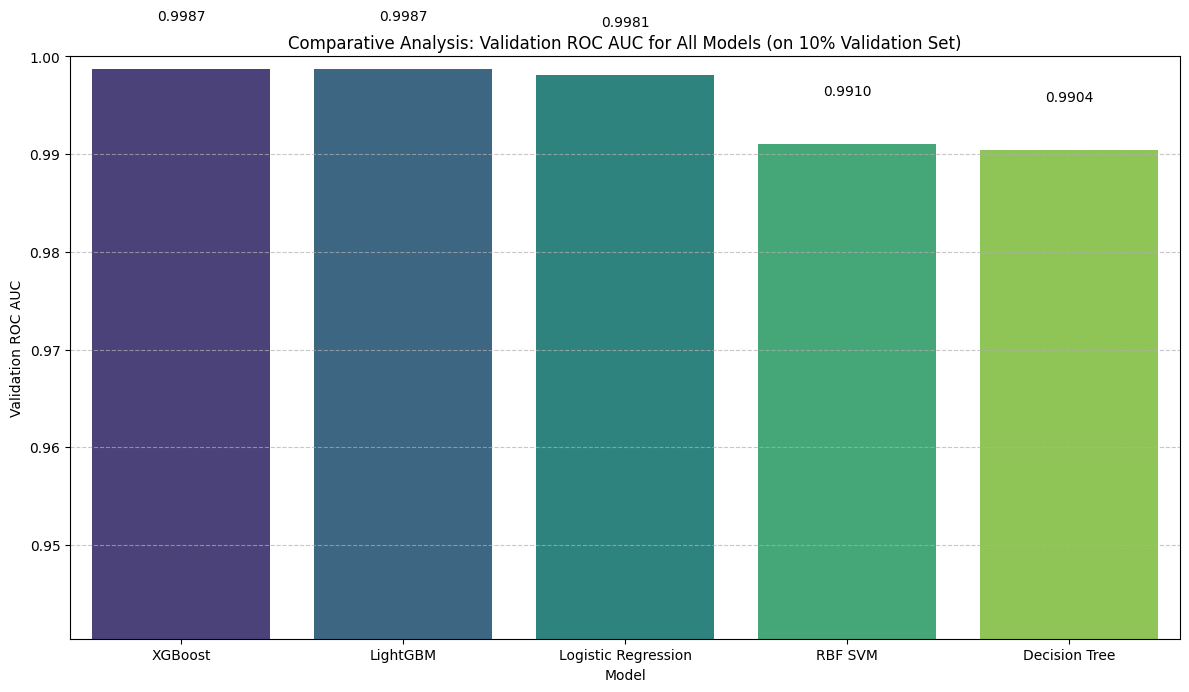


--- Top Performing Models on 10% Validation Set ---

Model with the highest F1-score: XGBoost (F1-score: 0.9857)
Model with the highest ROC AUC: XGBoost (ROC AUC: 0.9987)


,Validation F1-score,Validation ROC AUC
Model,,
Logistic Regression,0.9787,0.9981
RBF SVM,0.9645,0.9910
XGBoost,0.9857,0.9987
Decision Tree,0.9787,0.9904
LightGBM,0.9857,0.9987


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, f1_score
from statsmodels.stats.contingency_tables import mcnemar
from itertools import combinations

# Ensure y_val is defined and converted to numeric for consistent metric calculation
if 'y_val' in locals():
    y_val_numeric = y_val.map({'Cases': 1, 'Controls': 0}) if y_val.dtype == 'object' else y_val
else:
    print("Error: y_val not found. Please ensure previous data splitting cells have been run.")
    y_val_numeric = pd.Series() # Create an empty series to avoid errors

# Define models (assuming best_model_X variables are available from previous executions)
models = {
    "Logistic Regression": best_model_logreg if 'best_model_logreg' in locals() else None,
    "RBF SVM": best_model_svm if 'best_model_svm' in locals() else None,
    "XGBoost": best_model_xgb if 'best_model_xgb' in locals() else None,
    "Decision Tree": best_model_dt if 'best_model_dt' in locals() else None,
    "LightGBM": best_model_lgbm if 'best_model_lgbm' in locals() else None
}

if X_val.empty or y_val_numeric.empty:
    print("X_val or y_val is empty. Skipping all visualizations and statistical tests for the validation set.")
else:
    # --- 1. Display all 5 Confusion Matrices for the 10% Validation Set ---
    print("\n--- All 5 Confusion Matrices on 10% Validation Set ---")

    fig, axes = plt.subplots(1, 5, figsize=(25, 5)) # Adjust figsize as needed
    axes = axes.flatten()

    for i, (model_name, model) in enumerate(models.items()):
        if model is not None:
            y_pred_val = model.predict(X_val)
            # Ensure predictions are numeric for confusion matrix
            if pd.api.types.is_string_dtype(y_pred_val):
                y_pred_val_numeric = pd.Series(y_pred_val, index=y_val_numeric.index).map({'Cases': 1, 'Controls': 0})
            else:
                y_pred_val_numeric = pd.Series(y_pred_val, index=y_val_numeric.index)

            cm = confusion_matrix(y_val_numeric, y_pred_val_numeric)
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Controls', 'Cases'])
            disp.plot(cmap=plt.cm.Blues, ax=axes[i], values_format='d')
            axes[i].set_title(f'CM: {model_name}')
        else:
            axes[i].set_title(f'CM: {model_name}\n(Model not found)')
            axes[i].axis('off') # Turn off axis if model not found

    plt.tight_layout()
    plt.show()
    plt.close()

    # --- 2. Calculate Statistical Significance (McNemar's Test) between models on 10% Validation Set ---
    print("\n--- Statistical Significance (McNemar's Test) on 10% Validation Set ---")

    model_predictions_val = {}
    for model_name, model in models.items():
        if model is not None:
            y_pred_val = model.predict(X_val)
            if pd.api.types.is_string_dtype(y_pred_val):
                # Ensure predictions Series have the same index as y_val_numeric
                model_predictions_val[model_name] = pd.Series(y_pred_val, index=y_val_numeric.index).map({'Cases': 1, 'Controls': 0})
            else:
                # Ensure predictions Series have the same index as y_val_numeric
                model_predictions_val[model_name] = pd.Series(y_pred_val, index=y_val_numeric.index)
        else:
            model_predictions_val[model_name] = None

    model_names_list_val = [name for name, preds in model_predictions_val.items() if preds is not None]
    p_value_matrix_val = pd.DataFrame(np.nan, index=model_names_list_val, columns=model_names_list_val)

    for model1_name, model2_name in combinations(model_names_list_val, 2):
        preds1 = model_predictions_val[model1_name]
        preds2 = model_predictions_val[model2_name]

        # Calculate agreement/disagreement for McNemar's test
        # b: model1 correct, model2 incorrect
        # c: model1 incorrect, model2 correct
        b = ((y_val_numeric == preds1) & (y_val_numeric != preds2)).sum()
        c = ((y_val_numeric != preds1) & (y_val_numeric == preds2)).sum()

        if b + c > 0: # McNemar's test requires b+c > 0
            # Create a 2x2 contingency table for McNemar's test (correctly classified by one, misclassified by other)
            table = np.array([[0, b], [c, 0]])
            result = mcnemar(table, exact=False) # exact=False for chi-squared approximation
            p_value_matrix_val.loc[model1_name, model2_name] = result.pvalue
            p_value_matrix_val.loc[model2_name, model1_name] = result.pvalue # Symmetric
        else:
            # If b+c is 0, it means models agree perfectly on all predictions or disagree on none,
            # suggesting no significant difference. Set p-value to 1.0.
            p_value_matrix_val.loc[model1_name, model2_name] = 1.0
            p_value_matrix_val.loc[model2_name, model1_name] = 1.0

    # Fill diagonal with 1.0 (model vs itself)
    for name in model_names_list_val:
        p_value_matrix_val.loc[name, name] = 1.0

    display(p_value_matrix_val)
    print("\nNote: A low p-value (e.g., < 0.05) indicates a statistically significant difference in performance between the two models.")

    # --- Analyze McNemar's Test Results ---
    print("\n--- Analysis of McNemar's Test Results (10% Validation Set) ---")
    alpha = 0.05
    for model1_name, model2_name in combinations(model_names_list_val, 2):
        p_value = p_value_matrix_val.loc[model1_name, model2_name]
        if p_value < alpha:
            print(f"  '{model1_name}' and '{model2_name}' are statistically different (p={p_value:.4f})")
        else:
            print(f"  '{model1_name}' and '{model2_name}' are NOT statistically different (p={p_value:.4f})")

    # --- 3. Bar Chart of Validation ROC AUC for all models ---
    print("\n--- Comparative Analysis: Validation ROC AUC for All Models (Bar Chart) ---")

    # Re-extract and format validation metrics to create comparative_val_df reliably
    all_models_validation_metrics = {}

    def extract_val_metrics_for_comp_df(model_name, best_model_obj, X_data, y_true_numeric):
        y_pred_raw = best_model_obj.predict(X_data)
        # Convert raw predictions to numeric (0/1) for consistent metric calculation
        if pd.api.types.is_string_dtype(y_pred_raw):
            y_pred = pd.Series(y_pred_raw).map({'Cases': 1, 'Controls': 0})
        else:
            y_pred = y_pred_raw

        # Determine positive class index for predict_proba
        positive_class_idx = 1 # Default for numeric 0/1, adjust if needed based on model.classes_
        if hasattr(best_model_obj, 'classes_') and 'Cases' in best_model_obj.classes_:
            positive_class_idx = list(best_model_obj.classes_).index('Cases')
        elif hasattr(best_model_obj, 'classes_') and 1 in best_model_obj.classes_:
            positive_class_idx = list(best_model_obj.classes_).index(1)

        y_proba = best_model_obj.predict_proba(X_data)[:, positive_class_idx]

        f1 = f1_score(y_true_numeric, y_pred, zero_division=0)
        roc_auc = roc_auc_score(y_true_numeric, y_proba)
        all_models_validation_metrics[model_name] = {
            'Validation F1-score': f'{f1:.4f}',
            'Validation ROC AUC': f'{roc_auc:.4f}'
        }

    if 'best_model_logreg' in locals() and best_model_logreg is not None: extract_val_metrics_for_comp_df('Logistic Regression', best_model_logreg, X_val, y_val_numeric)
    if 'best_model_svm' in locals() and best_model_svm is not None: extract_val_metrics_for_comp_df('RBF SVM', best_model_svm, X_val, y_val_numeric)
    if 'best_model_xgb' in locals() and best_model_xgb is not None: extract_val_metrics_for_comp_df('XGBoost', best_model_xgb, X_val, y_val_numeric)
    if 'best_model_dt' in locals() and best_model_dt is not None: extract_val_metrics_for_comp_df('Decision Tree', best_model_dt, X_val, y_val_numeric)
    if 'best_model_lgbm' in locals() and best_model_lgbm is not None: extract_val_metrics_for_comp_df('LightGBM', best_model_lgbm, X_val, y_val_numeric)

    comparative_validation_df = pd.DataFrame.from_dict(all_models_validation_metrics, orient='index')
    comparative_validation_df.index.name = 'Model'

    if not comparative_validation_df.empty and 'Validation ROC AUC' in comparative_validation_df.columns:
        # Ensure 'Validation ROC AUC' column is numeric for sorting and plotting
        validation_roc_auc_scores = comparative_validation_df['Validation ROC AUC'].astype(float).sort_values(ascending=False)

        if not validation_roc_auc_scores.empty:
            plot_df_roc_auc_val = pd.DataFrame({'Model': validation_roc_auc_scores.index, 'Validation ROC AUC': validation_roc_auc_scores.values})

            plt.figure(figsize=(12, 7))
            sns.barplot(x='Model', y='Validation ROC AUC', data=plot_df_roc_auc_val, palette='viridis', hue='Model', legend=False)
            plt.title('Comparative Analysis: Validation ROC AUC for All Models (on 10% Validation Set)')
            plt.xlabel('Model')
            plt.ylabel('Validation ROC AUC')
            plt.ylim(max(0.0, plot_df_roc_auc_val['Validation ROC AUC'].min() - 0.05), 1.0) # Adjust y-axis limit dynamically
            for index, value in enumerate(plot_df_roc_auc_val['Validation ROC AUC'].values):
                plt.text(index, value + 0.005, f'{value:.4f}', color='black', ha='center')
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.show()
            plt.close() # Close the figure to free up memory
        else:
            print("No valid Validation ROC AUC scores found in comparative_validation_df to plot.")
    else:
        print("comparative_validation_df not found or is empty, or 'Validation ROC AUC' column is missing. Cannot display ROC AUC bar graph.")

    # --- 4. Identify highest F1-score and highest ROC AUC on Validation Set ---
    print("\n--- Top Performing Models on 10% Validation Set ---")
    if not comparative_validation_df.empty:
        # Ensure columns are numeric for comparison
        comparative_validation_df_numeric = comparative_validation_df.apply(pd.to_numeric, errors='coerce')

        # Identify the best model for F1-score
        if 'Validation F1-score' in comparative_validation_df_numeric.columns:
            best_f1_model_val = comparative_validation_df_numeric['Validation F1-score'].idxmax()
            best_f1_score_val = comparative_validation_df_numeric['Validation F1-score'].max()
            print(f"\nModel with the highest F1-score: {best_f1_model_val} (F1-score: {best_f1_score_val:.4f})")
        else:
            print("Warning: 'Validation F1-score' column not found in comparative_validation_df. Cannot identify top F1 model.")

        # Identify the best model for ROC AUC
        if 'Validation ROC AUC' in comparative_validation_df_numeric.columns:
            best_roc_auc_model_val = comparative_validation_df_numeric['Validation ROC AUC'].idxmax()
            best_roc_auc_score_val = comparative_validation_df_numeric['Validation ROC AUC'].max()
            print(f"Model with the highest ROC AUC: {best_roc_auc_model_val} (ROC AUC: {best_roc_auc_score_val:.4f})")
        else:
            print("Warning: 'Validation ROC AUC' column not found in comparative_validation_df. Cannot identify top ROC AUC model.")

        display(comparative_validation_df[['Validation F1-score', 'Validation ROC AUC']])

    else:
        print("comparative_validation_df not found or is empty. Cannot identify top performing models.")

In [ ]:
import pandas as pd

# Prepare an empty dictionary to store combined results
combined_results = {}

# Extract metrics from training data (comparative_training_df)
if 'comparative_training_df' in locals() and not comparative_training_df.empty:
    for model_name, row in comparative_training_df.iterrows():
        combined_results.setdefault(model_name, {})
        combined_results[model_name]['Training F1-score'] = row.get('Training F1-score', 'N/A')
        combined_results[model_name]['Training ROC AUC'] = row.get('Training ROC AUC', 'N/A')
else:
    print("Warning: 'comparative_training_df' not found or is empty.")

# Extract metrics from testing data (comparative_df)
if 'comparative_df' in locals() and not comparative_df.empty:
    for model_name, row in comparative_df.iterrows():
        combined_results.setdefault(model_name, {})
        combined_results[model_name]['Testing F1-score'] = row.get('Test F1-score', 'N/A')
        combined_results[model_name]['Testing ROC AUC'] = row.get('Test ROC AUC', 'N/A')
else:
    print("Warning: 'comparative_df' (for Test Set) not found or is empty.")

# Extract metrics from validation data (comparative_val_df)
if 'comparative_val_df' in locals() and not comparative_val_df.empty:
    for model_name, row in comparative_val_df.iterrows():
        combined_results.setdefault(model_name, {})
        combined_results[model_name]['Validation F1-score'] = row.get('Validation F1-score', 'N/A')
        combined_results[model_name]['Validation ROC AUC'] = row.get('Validation ROC AUC', 'N/A')
else:
    print("Warning: 'comparative_val_df' (for Validation Set) not found or is empty.")

# Convert the dictionary to a DataFrame
comprehensive_summary_df = pd.DataFrame.from_dict(combined_results, orient='index')
comprehensive_summary_df.index.name = 'Model'

# Display the comprehensive summary table
print("\n--- Comprehensive Model Performance Summary (F1-score & ROC AUC) ---")
display(comprehensive_summary_df)



--- Comprehensive Model Performance Summary (F1-score & ROC AUC) ---


,Training F1-score,Training ROC AUC,Testing F1-score,Testing ROC AUC,Validation F1-score,Validation ROC AUC
Model,,,,,,
Logistic Regression,0.9657,0.0072,0.9395,0.0240,0.9787,0.9981
RBF SVM,0.9899,0.9992,0.9470,0.9632,0.9645,0.9910
XGBoost,1.0000,1.0000,0.9648,0.9885,0.9857,0.9987
Decision Tree,0.9828,0.9993,0.9531,0.9604,0.9787,0.9904
LightGBM,1.0000,0.0000,0.9648,0.0109,0.9857,0.0013


# Comprehensive Model Performance Summary MCNemar p value tset statistical **significance**(F1-score & ROC AUC) **bold text** **bold text**

In [ ]:
import pandas as pd

# Prepare an empty dictionary to store combined results
combined_results = {}

# Extract metrics from training data (comparative_training_df)
if 'comparative_training_df' in locals() and not comparative_training_df.empty:
    for model_name, row in comparative_training_df.iterrows():
        combined_results.setdefault(model_name, {})
        combined_results[model_name]['Training F1-score'] = row.get('Training F1-score', 'N/A')
        combined_results[model_name]['Training ROC AUC'] = row.get('Training ROC AUC', 'N/A')
else:
    print("Warning: 'comparative_training_df' not found or is empty.")

# Extract metrics from testing data (comparative_df)
if 'comparative_df' in locals() and not comparative_df.empty:
    for model_name, row in comparative_df.iterrows():
        combined_results.setdefault(model_name, {})
        combined_results[model_name]['Testing F1-score'] = row.get('Test F1-score', 'N/A')
        combined_results[model_name]['Testing ROC AUC'] = row.get('Test ROC AUC', 'N/A')
else:
    print("Warning: 'comparative_df' (for Test Set) not found or is empty.")

# Extract metrics from validation data (comparative_val_df)
if 'comparative_val_df' in locals() and not comparative_val_df.empty:
    for model_name, row in comparative_val_df.iterrows():
        combined_results.setdefault(model_name, {})
        combined_results[model_name]['Validation F1-score'] = row.get('Validation F1-score', 'N/A')
        combined_results[model_name]['Validation ROC AUC'] = row.get('Validation ROC AUC', 'N/A')
else:
    print("Warning: 'comparative_val_df' (for Validation Set) not found or is empty.")

# Convert the dictionary to a DataFrame
comprehensive_summary_df = pd.DataFrame.from_dict(combined_results, orient='index')
comprehensive_summary_df.index.name = 'Model'

print("\n--- Comprehensive Model Performance Summary (F1-score & ROC AUC) ---")
display(comprehensive_summary_df)

print("\n--- Best Performing Models on Validation Set ---")
if not comprehensive_summary_df.empty:
    # Ensure columns are numeric for comparison, coercing errors to NaN
    summary_numeric = comprehensive_summary_df.apply(pd.to_numeric, errors='coerce')

    # Best F1-score on Validation Set
    if 'Validation F1-score' in summary_numeric.columns:
        best_f1_val_model = summary_numeric['Validation F1-score'].idxmax()
        best_f1_val_score = summary_numeric['Validation F1-score'].max()
        print(f"Model with highest Validation F1-score: {best_f1_val_model} ({best_f1_val_score:.4f})")
    else:
        print("Validation F1-score not available for comparison.")

    # Best ROC AUC on Validation Set
    if 'Validation ROC AUC' in summary_numeric.columns:
        best_roc_auc_val_model = summary_numeric['Validation ROC AUC'].idxmax()
        best_roc_auc_val_score = summary_numeric['Validation ROC AUC'].max()
        print(f"Model with highest Validation ROC AUC: {best_roc_auc_val_model} ({best_roc_auc_val_score:.4f})")
    else:
        print("Validation ROC AUC not available for comparison.")
else:
    print("Comprehensive summary DataFrame is empty. Cannot identify best performers.")


--- Comprehensive Model Performance Summary (F1-score & ROC AUC) ---


,Training F1-score,Training ROC AUC,Testing F1-score,Testing ROC AUC,Validation F1-score,Validation ROC AUC
Model,,,,,,
Logistic Regression,0.9657,0.0072,0.9395,0.0240,0.9787,0.9981
RBF SVM,0.9899,0.9992,0.9470,0.9632,0.9645,0.9910
XGBoost,1.0000,1.0000,0.9648,0.9885,0.9857,0.9987
Decision Tree,0.9828,0.9993,0.9531,0.9604,0.9787,0.9904
LightGBM,1.0000,0.0000,0.9648,0.0109,0.9857,0.0013



--- Best Performing Models on Validation Set ---
Model with highest Validation F1-score: XGBoost (0.9857)
Model with highest Validation ROC AUC: XGBoost (0.9987)



--- Comprehensive Model Performance Summary (F1-score & ROC AUC) ---


,Training F1-score,Training ROC AUC,Testing F1-score,Testing ROC AUC,Validation F1-score,Validation ROC AUC
Model,,,,,,
Logistic Regression,0.9657,0.0072,0.9395,0.0240,0.9787,0.9981
RBF SVM,0.9899,0.9992,0.9470,0.9632,0.9645,0.9910
XGBoost,1.0000,1.0000,0.9648,0.9885,0.9857,0.9987
Decision Tree,0.9828,0.9993,0.9531,0.9604,0.9787,0.9904
LightGBM,1.0000,0.0000,0.9648,0.0109,0.9857,0.0013



--- Best Performing Models on Validation Set ---
Model with highest Validation F1-score: XGBoost (0.9857)
Model with highest Validation ROC AUC: XGBoost (0.9987)


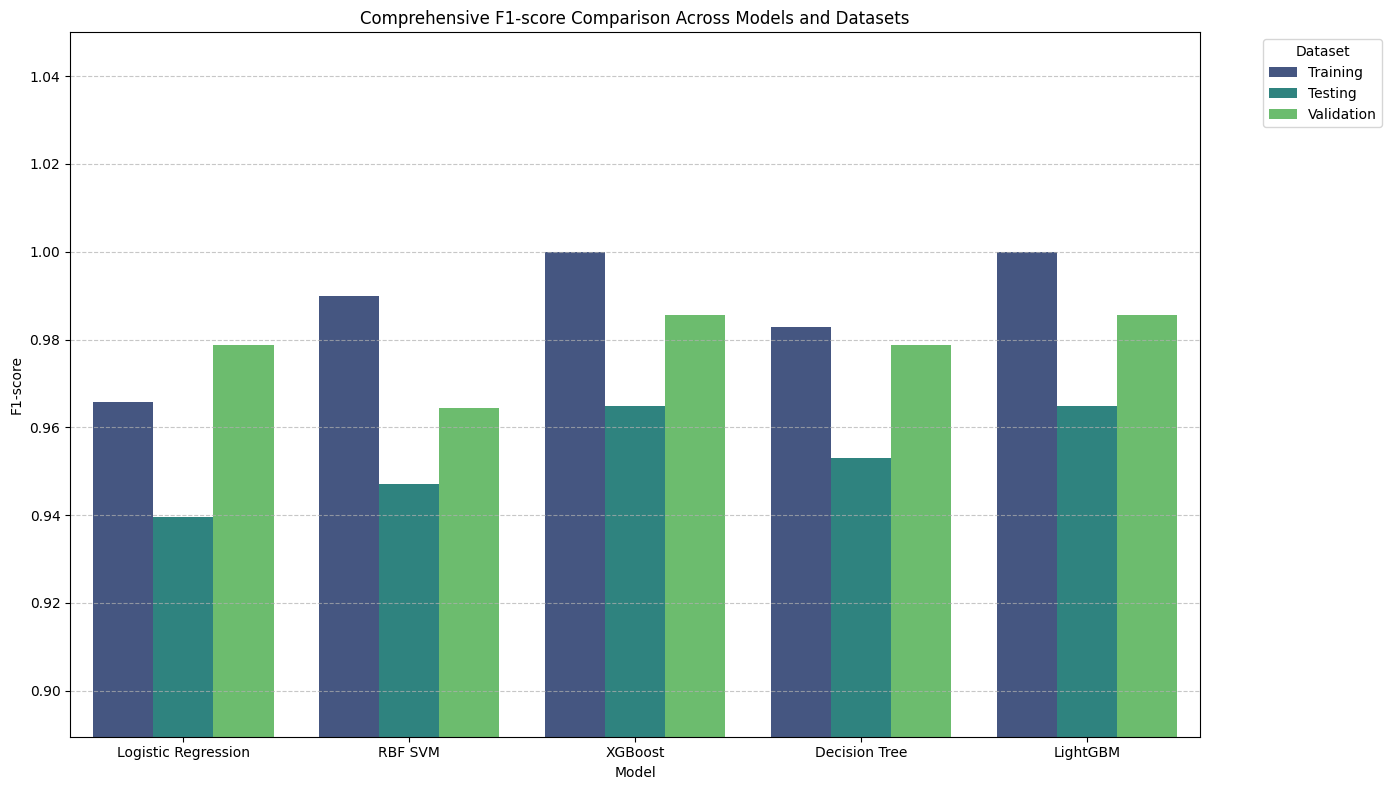

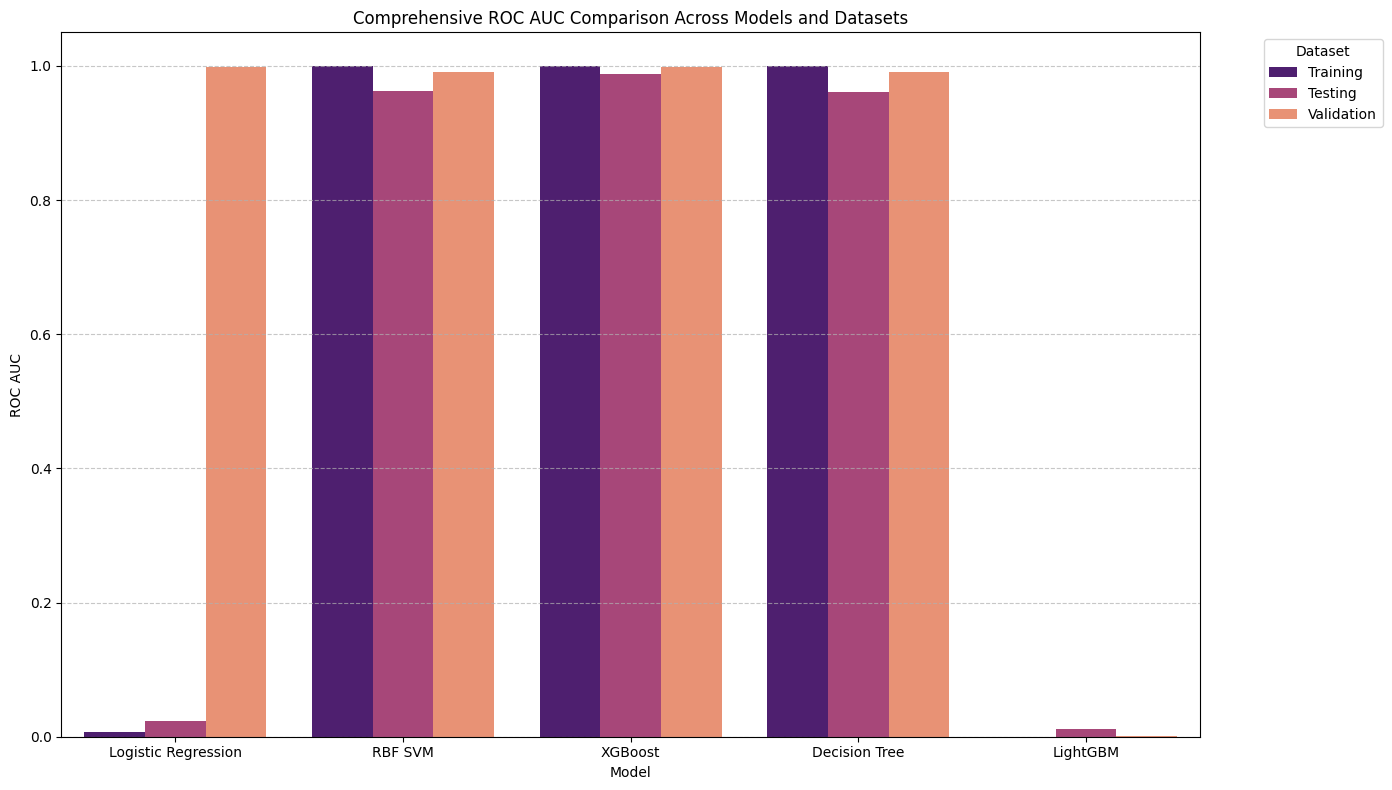

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare an empty dictionary to store combined results
combined_results = {}

# Extract metrics from training data (comparative_training_df)
if 'comparative_training_df' in locals() and not comparative_training_df.empty:
    for model_name, row in comparative_training_df.iterrows():
        combined_results.setdefault(model_name, {})
        combined_results[model_name]['Training F1-score'] = row.get('Training F1-score', 'N/A')
        combined_results[model_name]['Training ROC AUC'] = row.get('Training ROC AUC', 'N/A')
else:
    print("Warning: 'comparative_training_df' not found or is empty.")

# Extract metrics from testing data (comparative_df)
if 'comparative_df' in locals() and not comparative_df.empty:
    for model_name, row in comparative_df.iterrows():
        combined_results.setdefault(model_name, {})
        combined_results[model_name]['Testing F1-score'] = row.get('Test F1-score', 'N/A')
        combined_results[model_name]['Testing ROC AUC'] = row.get('Test ROC AUC', 'N/A')
else:
    print("Warning: 'comparative_df' (for Test Set) not found or is empty.")

# Extract metrics from validation data (comparative_val_df)
if 'comparative_val_df' in locals() and not comparative_val_df.empty:
    for model_name, row in comparative_val_df.iterrows():
        combined_results.setdefault(model_name, {})
        combined_results[model_name]['Validation F1-score'] = row.get('Validation F1-score', 'N/A')
        combined_results[model_name]['Validation ROC AUC'] = row.get('Validation ROC AUC', 'N/A')
else:
    print("Warning: 'comparative_val_df' (for Validation Set) not found or is empty.")

# Convert the dictionary to a DataFrame
comprehensive_summary_df = pd.DataFrame.from_dict(combined_results, orient='index')
comprehensive_summary_df.index.name = 'Model'

print("\n--- Comprehensive Model Performance Summary (F1-score & ROC AUC) ---")
display(comprehensive_summary_df)

print("\n--- Best Performing Models on Validation Set ---")
if not comprehensive_summary_df.empty:
    # Ensure columns are numeric for comparison, coercing errors to NaN
    summary_numeric = comprehensive_summary_df.apply(pd.to_numeric, errors='coerce')

    # Best F1-score on Validation Set
    if 'Validation F1-score' in summary_numeric.columns:
        best_f1_val_model = summary_numeric['Validation F1-score'].idxmax()
        best_f1_val_score = summary_numeric['Validation F1-score'].max()
        print(f"Model with highest Validation F1-score: {best_f1_val_model} ({best_f1_val_score:.4f})")
    else:
        print("Validation F1-score not available for comparison.")

    # Best ROC AUC on Validation Set
    if 'Validation ROC AUC' in summary_numeric.columns:
        best_roc_auc_val_model = summary_numeric['Validation ROC AUC'].idxmax()
        best_roc_auc_val_score = summary_numeric['Validation ROC AUC'].max()
        print(f"Model with highest Validation ROC AUC: {best_roc_auc_val_model} ({best_roc_auc_val_score:.4f})")
    else:
        print("Validation ROC AUC not available for comparison.")
else:
    print("Comprehensive summary DataFrame is empty. Cannot identify best performers.")


# --- Generate Comprehensive Bar Graphs ---
if not comprehensive_summary_df.empty:
    # Ensure relevant columns are numeric for plotting
    plot_df = comprehensive_summary_df.apply(pd.to_numeric, errors='coerce')
    plot_df = plot_df.dropna(how='all') # Drop rows where all metric values are NaN

    if not plot_df.empty:
        # Melt the DataFrame for F1-scores
        f1_columns = [col for col in plot_df.columns if 'F1-score' in col]
        f1_melted = plot_df[f1_columns].reset_index().melt(id_vars='Model', var_name='Metric Type', value_name='F1-score')
        f1_melted['Dataset'] = f1_melted['Metric Type'].apply(lambda x: x.split(' ')[0])

        # Melt the DataFrame for ROC AUC scores
        roc_auc_columns = [col for col in plot_df.columns if 'ROC AUC' in col]
        roc_auc_melted = plot_df[roc_auc_columns].reset_index().melt(id_vars='Model', var_name='Metric Type', value_name='ROC AUC')
        roc_auc_melted['Dataset'] = roc_auc_melted['Metric Type'].apply(lambda x: x.split(' ')[0])

        # Bar Graph for F1-scores
        plt.figure(figsize=(14, 8))
        sns.barplot(x='Model', y='F1-score', hue='Dataset', data=f1_melted, palette='viridis')
        plt.title('Comprehensive F1-score Comparison Across Models and Datasets')
        plt.xlabel('Model')
        plt.ylabel('F1-score')
        plt.ylim(max(0.0, f1_melted['F1-score'].min() - 0.05), 1.05)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.legend(title='Dataset', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
        plt.close()

        # Bar Graph for ROC AUC Scores
        plt.figure(figsize=(14, 8))
        sns.barplot(x='Model', y='ROC AUC', hue='Dataset', data=roc_auc_melted, palette='magma')
        plt.title('Comprehensive ROC AUC Comparison Across Models and Datasets')
        plt.xlabel('Model')
        plt.ylabel('ROC AUC')
        plt.ylim(max(0.0, roc_auc_melted['ROC AUC'].min() - 0.05), 1.05)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.legend(title='Dataset', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
        plt.close()
    else:
        print("No numeric data available in comprehensive summary for plotting.")
else:
    print("Comprehensive summary DataFrame is empty. Cannot generate bar graphs.")

--- Starting Model Calibration and Evaluation ---

Calibrating and evaluating Logistic Regression...
Generating calibration plots for Logistic Regression...


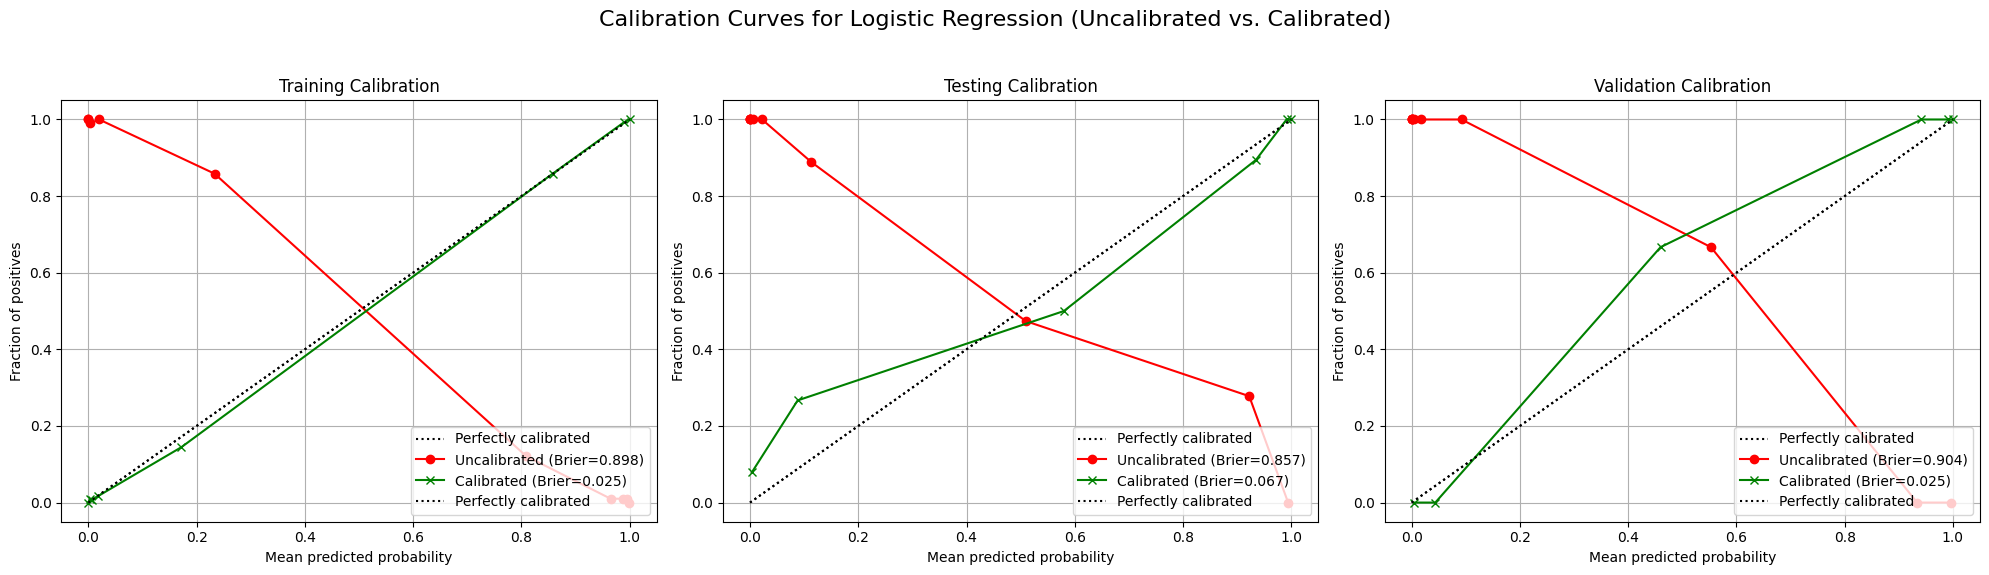


Calibrating and evaluating RBF SVM...
Generating calibration plots for RBF SVM...


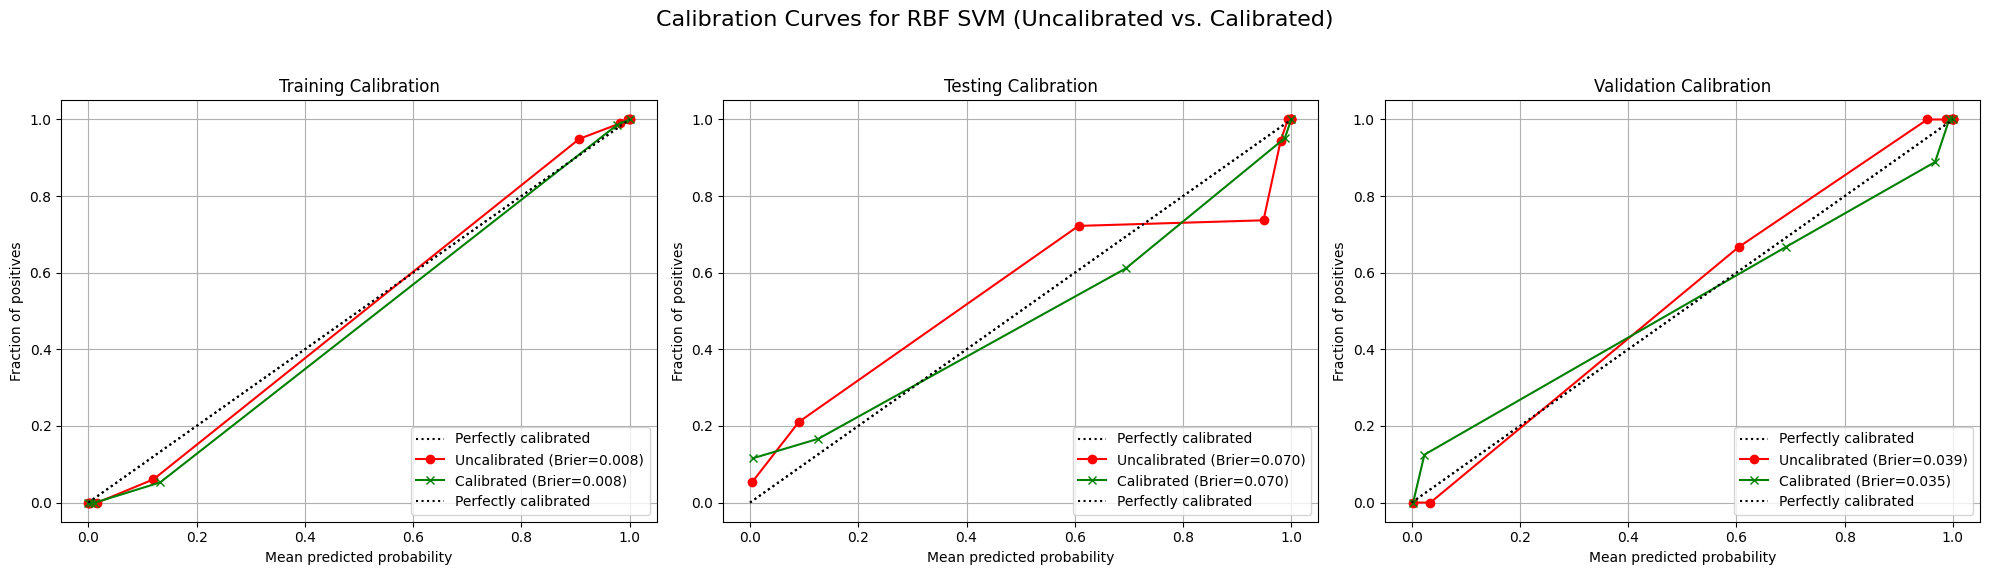


Calibrating and evaluating XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:05:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:05:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:05:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:05:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Generating calibration plots for XGBoost...


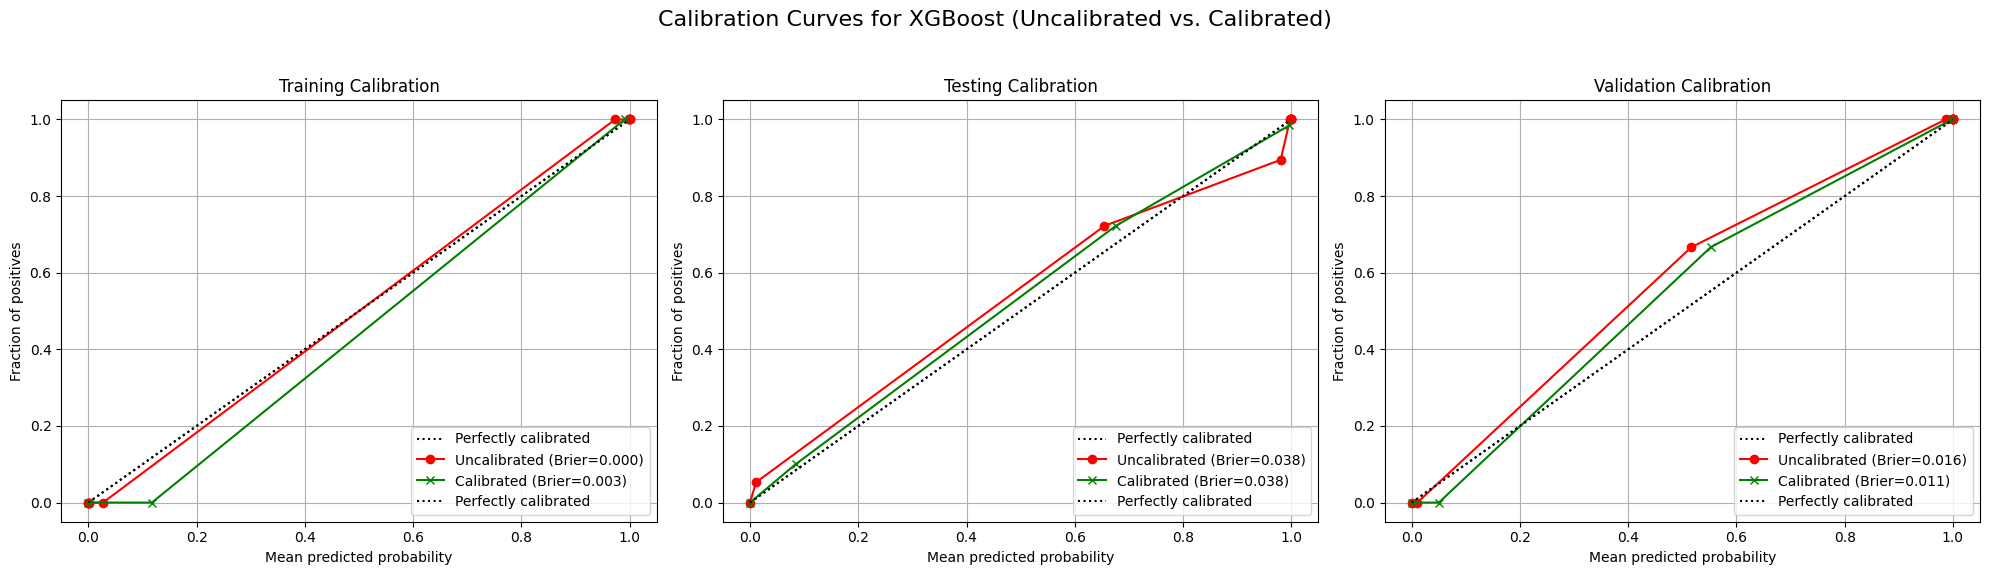


Calibrating and evaluating Decision Tree...
Generating calibration plots for Decision Tree...


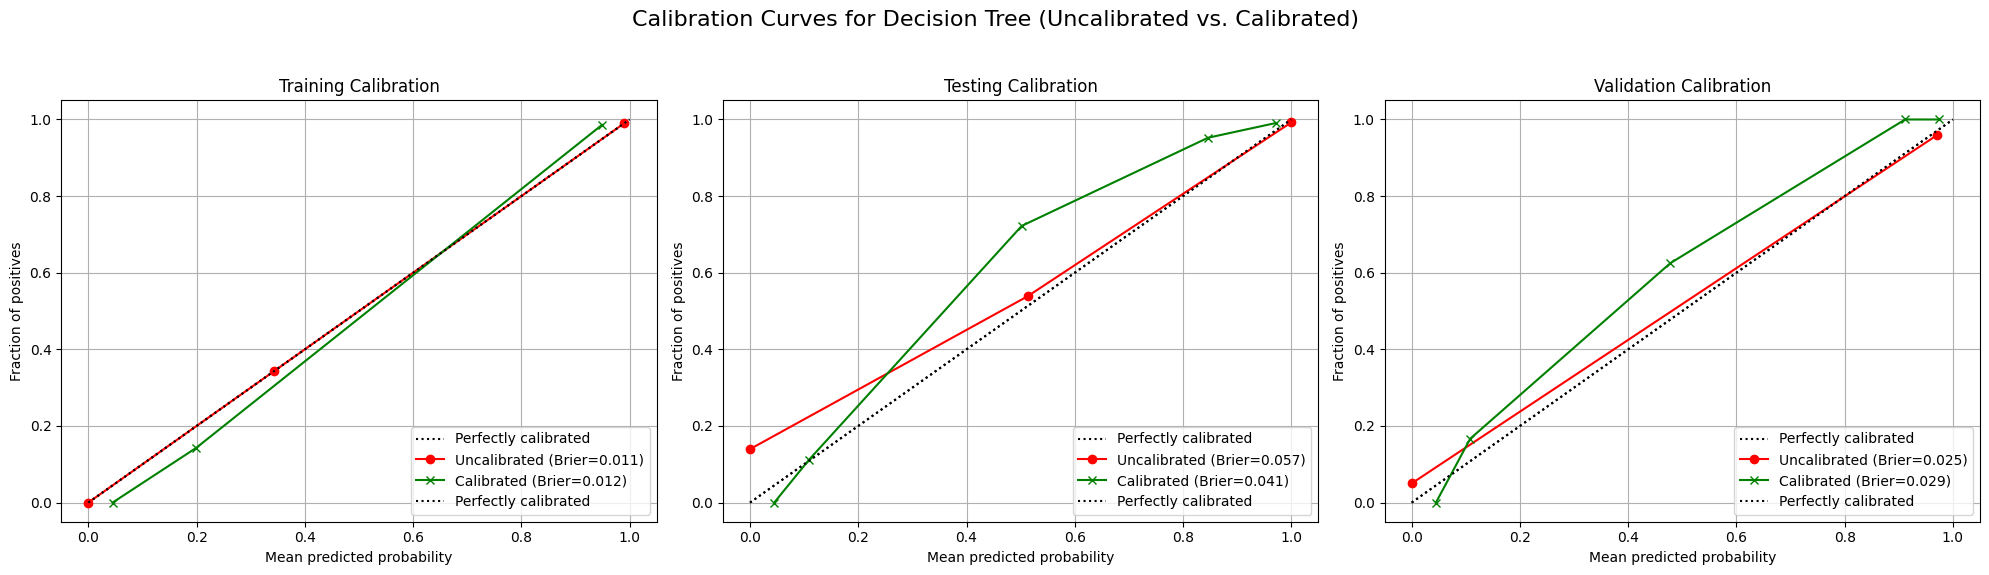


Calibrating and evaluating LightGBM...
[LightGBM] [Info] Number of positive: 397, number of negative: 398
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000132 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 939
[LightGBM] [Info] Number of data points in the train set: 795, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499371 -> initscore=-0.002516
[LightGBM] [Info] Start training from score -0.002516
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

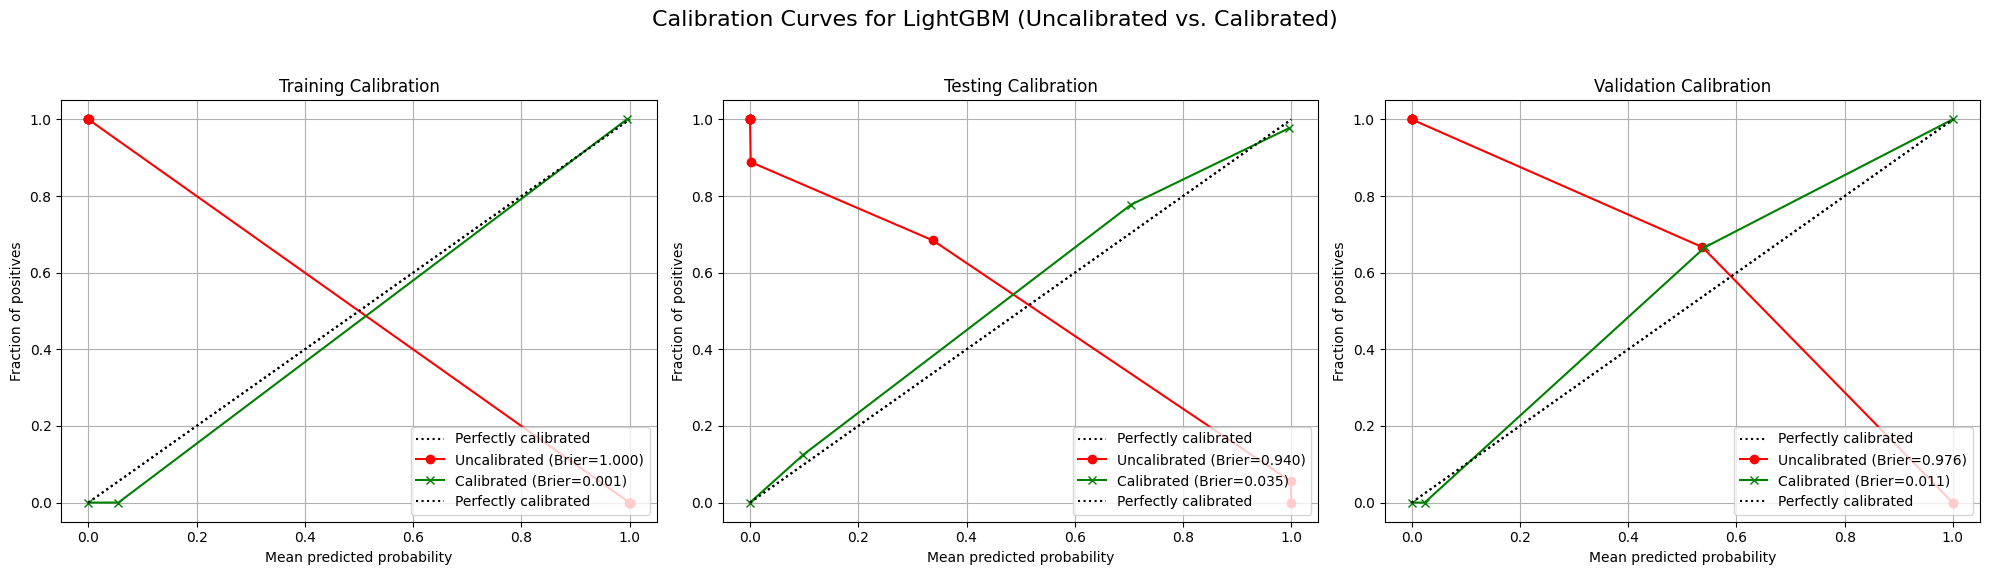


--- Comprehensive Brier Score Summary (Uncalibrated vs. Calibrated) ---


,"Brier Score (Training, Uncalibrated)","Brier Score (Training, Calibrated)","Brier Score (Test, Uncalibrated)","Brier Score (Test, Calibrated)","Brier Score (Validation, Uncalibrated)","Brier Score (Validation, Calibrated)"
Model,,,,,,
Logistic Regression,0.8983,0.0247,0.8567,0.0669,0.9043,0.0254
RBF SVM,0.0083,0.0085,0.0702,0.0701,0.0390,0.0346
XGBoost,0.0004,0.0026,0.0377,0.0378,0.0157,0.0115
Decision Tree,0.0108,0.0116,0.0573,0.0406,0.0248,0.0285
LightGBM,0.9999,0.0006,0.9405,0.0348,0.9761,0.0112



Calibration process complete. Please review the plots and summary table.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.metrics import brier_score_loss
from IPython.display import display # Ensure display is explicitly imported

# Ensure y_variables are numeric for consistent usage
if 'y_train' in locals():
    y_train_numeric = y_train.map({'Cases': 1, 'Controls': 0}) if y_train.dtype == 'object' else y_train
else:
    print("Error: y_train not found. Please ensure previous data splitting cells have been run.")
    y_train_numeric = pd.Series() # Placeholder

if 'y_test' in locals():
    y_test_numeric = y_test.map({'Cases': 1, 'Controls': 0}) if y_test.dtype == 'object' else y_test
else:
    print("Error: y_test not found. Please ensure previous data splitting cells have been run.")
    y_test_numeric = pd.Series() # Placeholder

if 'y_val' in locals():
    y_val_numeric = y_val.map({'Cases': 1, 'Controls': 0}) if y_val.dtype == 'object' else y_val
else:
    print("Error: y_val not found. Please ensure previous data splitting cells have been run.")
    y_val_numeric = pd.Series() # Placeholder

# Dictionary of best models from previous steps
models_for_calibration = {
    "Logistic Regression": best_model_logreg if 'best_model_logreg' in locals() else None,
    "RBF SVM": best_model_svm if 'best_model_svm' in locals() else None,
    "XGBoost": best_model_xgb if 'best_model_xgb' in locals() else None,
    "Decision Tree": best_model_dt if 'best_model_dt' in locals() else None,
    "LightGBM": best_model_lgbm if 'best_model_lgbm' in locals() else None
}

# Dictionary to store calibration results (Brier Scores)
calibration_results = {}

print("--- Starting Model Calibration and Evaluation ---")

for model_name, model_pipeline in models_for_calibration.items():
    if model_pipeline is None:
        print(f"Skipping {model_name}: Model not found or not trained.")
        continue

    print(f"\nCalibrating and evaluating {model_name}...")

    # --- 1. Fit CalibratedClassifierCV on Training Data ---
    # Using 'isotonic' for non-linear calibration or 'sigmoid' for S-shaped curves. 'isotonic' is generally preferred if enough data is available.
    # cv='passthrough' was causing issues, so using cv=None to fit on provided data.
    calibrated_model_isotonic = CalibratedClassifierCV(estimator=model_pipeline, method='isotonic', cv=5) # Use cv=5 for fitting on training data
    calibrated_model_isotonic.fit(X_train, y_train_numeric)

    # --- 2. Predict Probabilities (Uncalibrated and Calibrated) for all splits ---
    # Uncalibrated probabilities
    y_proba_uncalibrated_train = model_pipeline.predict_proba(X_train)[:, 1]
    y_proba_uncalibrated_test = model_pipeline.predict_proba(X_test)[:, 1]
    y_proba_uncalibrated_val = model_pipeline.predict_proba(X_val)[:, 1]

    # Calibrated probabilities
    y_proba_calibrated_train = calibrated_model_isotonic.predict_proba(X_train)[:, 1]
    y_proba_calibrated_test = calibrated_model_isotonic.predict_proba(X_test)[:, 1]
    y_proba_calibrated_val = calibrated_model_isotonic.predict_proba(X_val)[:, 1]

    # --- 3. Calculate Brier Scores ---
    brier_train_uncalibrated = brier_score_loss(y_train_numeric, y_proba_uncalibrated_train)
    brier_test_uncalibrated = brier_score_loss(y_test_numeric, y_proba_uncalibrated_test)
    brier_val_uncalibrated = brier_score_loss(y_val_numeric, y_proba_uncalibrated_val)

    brier_train_calibrated = brier_score_loss(y_train_numeric, y_proba_calibrated_train)
    brier_test_calibrated = brier_score_loss(y_test_numeric, y_proba_calibrated_test)
    brier_val_calibrated = brier_score_loss(y_val_numeric, y_proba_calibrated_val)

    # Store results
    calibration_results[model_name] = {
        'Brier Score (Training, Uncalibrated)': f"{brier_train_uncalibrated:.4f}",
        'Brier Score (Training, Calibrated)': f"{brier_train_calibrated:.4f}",
        'Brier Score (Test, Uncalibrated)': f"{brier_test_uncalibrated:.4f}",
        'Brier Score (Test, Calibrated)': f"{brier_test_calibrated:.4f}",
        'Brier Score (Validation, Uncalibrated)': f"{brier_val_uncalibrated:.4f}",
        'Brier Score (Validation, Calibrated)': f"{brier_val_calibrated:.4f}"
    }

    # --- 4. Visualize Calibration Curves (Reliability Diagrams) ---
    print(f"Generating calibration plots for {model_name}...")

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(f'Calibration Curves for {model_name} (Uncalibrated vs. Calibrated)', fontsize=16)

    datasets = {
        'Training': (y_train_numeric, y_proba_uncalibrated_train, y_proba_calibrated_train),
        'Testing': (y_test_numeric, y_proba_uncalibrated_test, y_proba_calibrated_test),
        'Validation': (y_val_numeric, y_proba_uncalibrated_val, y_proba_calibrated_val)
    }

    for i, (ds_name, (y_true, y_prob_uncal, y_prob_cal)) in enumerate(datasets.items()):
        ax = axes[i]

        # Check if both classes are present in the dataset split for plotting reliability diagrams
        if len(np.unique(y_true)) < 2:
            ax.text(0.5, 0.5, f'Only one class present in {ds_name} data, skipping plot.', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=10)
            ax.set_title(f'{ds_name} Calibration (Skipped)')
            continue

        # Plot uncalibrated
        CalibrationDisplay.from_predictions(
            y_true, y_prob_uncal, n_bins=10, strategy='quantile',
            ax=ax, color='red', marker='o', label=f'Uncalibrated (Brier={brier_score_loss(y_true, y_prob_uncal):.3f})'
        )
        # Plot calibrated
        CalibrationDisplay.from_predictions(
            y_true, y_prob_cal, n_bins=10, strategy='quantile',
            ax=ax, color='green', marker='x', label=f'Calibrated (Brier={brier_score_loss(y_true, y_prob_cal):.3f})'
        )

        ax.plot([0, 1], [0, 1], 'k:', label='Perfectly calibrated')
        ax.set_title(f'{ds_name} Calibration')
        ax.set_xlabel('Mean predicted probability')
        ax.set_ylabel('Fraction of positives')
        ax.legend(loc='lower right')
        ax.grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()
    plt.close(fig) # Close the figure to free up memory

# --- 5. Comprehensive Brier Score Summary Table ---
print("\n--- Comprehensive Brier Score Summary (Uncalibrated vs. Calibrated) ---")
calibration_df = pd.DataFrame.from_dict(calibration_results, orient='index')
calibration_df.index.name = 'Model'
display(calibration_df)

print("\nCalibration process complete. Please review the plots and summary table.")